<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks-EN/3.2-feature-extraction-with-pytorch-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tensor generation with PyTorch and Torchaudio for Mel(dB), Mel(dB)-Delta, Cochlea/Gammatonegram(dB)

In this notebook we perform **acoustic feature extraction** with PyTorch/Torchaudio/nnAudio (without Librosa), following a modular structure analogous to notebook [3.1-feature-extraction-rav-&-crema](https://github.com/AcSsalazar/the-color-of-emotions/blob/main/Notebooks-EN/3.1-feature-extraction-rav-%26-crema.ipynb)

**Pipeline:**
1. Imports and configuration
2. Dataset download + copy to SSD + duplicate cleanup
3. Metadata parsing + speaker-independent split (80/10/10)
4. Waveform preprocessing (resample → trim → normalization → padding)
5. Torch feature extraction: 3 channels — Mel(dB), Mel(dB)-Delta, Cochlea/Gammatonegram(dB)
6. Per-sample and per-channel z-score (no leakage)
7. Fixed data augmentation (only `surprised` × `train`)
8. Serialization: one `.pt` per split with `x`, `y`, `meta`, `class_to_idx`, `config`
9. Final sanity checks

## 1. Imports

In [1]:
# Install nnAudio if it is not available
!pip install nnAudio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.2 MB/s eta 0:00:00


In [2]:
# Imports
# -------------------------------------------------------
import os
import gc
import random
import logging
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import torch
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
#-------------------------------------------------------
from nnAudio import Spectrogram
from tqdm import tqdm
# Progress logger and runtime flag
# -------------------------------------------------------
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
logger = logging.getLogger(__name__)
torch.manual_seed(42)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


/usr/local/lib/python3.12/dist-packages/nnAudio/Spectrogram.py:4: Warning: importing Spectrogram subpackage will be deprecated soon. You should import the feature extractor from the feature subpackage. See actual documentation.
  warnings.warn(


Carrying out **acoustic feature extraction** with **Torchaudio** (PyTorch) lets us take advantage of **GPU** acceleration. This type of runtime is essential to optimize processing times for large volumes of data.

In this case we will extract the next features for our three tensor channels; we will use as a base the Mel spectrogram—thanks to its strong performance seen in many research studies.

We will configure the input with:

1. **Mel spectrogram:** due to excellent performance in research studies.
2. **Delta (first order):** to capture the dynamics of the Mel spectrogram.
3. **Cochlear spectrogram:** to incorporate a representation based on human auditory perception.

## 2. Configuration and paths

We determined that the most suitable value for the `MAX_DURATION` constant is **1.6 seconds**. This adjustment arises from the need to standardize spectrogram size based on the density of useful information (the actor’s voice).

The calculation follows the relationship:

$$MAX\_DURATION = \frac{Target\ Frames 	imes Hop\ Length}{Sample\ Rate}$$

Substituting the values defined for this experiment:

$$\frac{50 	imes 512}{16,000} = 1.6\ s$$

**Justification for the adjustment:**
In the previous pipeline version, where `MAX_DURATION = 3.0 s`, we obtained a temporal resolution of about 94 frames. Through a visual inspection of the dataset, we found that in most files the relevant acoustic information was concentrated between frames 30 and 50.

By adjusting the maximum duration to **1.6 seconds**, we guarantee that each spectrogram has exactly **50 frames**, removing redundant silence sections and optimizing input efficiency for the model.

In [3]:
# ── Audio parameters ──────────────────────────────────────────────────────
SAMPLE_RATE    = 16000   # Limitado por CREMA-D (16 kHz)
MIN_DURATION   = 0.5     # Minimum seconds; shorter samples are discarded
MAX_DURATION   = 1.6     # Maximum seconds after trim
N_MELS         = 60      # Bandas mel / bins gammatone
HOP_LENGTH     = 512     # Salto en samples
TARGET_SAMPLES = int(SAMPLE_RATE * MAX_DURATION)          # 25 600 samples
TARGET_FRAMES  = int(TARGET_SAMPLES / HOP_LENGTH) + 1     # ~50 frames
PAD_MODE       = "constant"  # Para padding de audios cortos

print(f"TARGET_SAMPLES={TARGET_SAMPLES}  TARGET_FRAMES={TARGET_FRAMES}")

# ── Paths ────────────────────────────────────────────────────────────────────
FAST_ROOT_DIR    = '/content/datasets'               # Directorio de trabajo (SSD session)
OUT_DIR_TENSORS  = '/content/split_pytorch_tensors'  # Salida final
os.makedirs(FAST_ROOT_DIR,   exist_ok=True)
os.makedirs(OUT_DIR_TENSORS, exist_ok=True)

TARGET_SAMPLES=25600  TARGET_FRAMES=51


## 3. Dataset download and preparation

We download RAVDESS and CREMA-D from Kaggle, copy them to local SSD, and remove the duplicate directory inside RAVDESS (`audio_speech_actors_01-24`).


In [4]:
# Download datasets from Kaggle
path       = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
path_crema = kagglehub.dataset_download("ejlok1/cremad")

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Using Colab cache for faster access to the 'cremad' dataset.


In [5]:
# Copy to local SSD for faster I/O
!cp -r {path}/* {FAST_ROOT_DIR}/
!cp -r {path_crema}/* {FAST_ROOT_DIR}/

**!Attention!**

The next step is essential to avoid overfitting due to duplicates in the RAVDESS dataset

In [6]:
# Remove duplicated RAVDESS folder
target_dir = os.path.join(FAST_ROOT_DIR, "audio_speech_actors_01-24")
if os.path.isdir(target_dir):
    shutil.rmtree(target_dir)
    print("Folder was deleted:", target_dir)
else:
    print("Path not found (already clean)")

Folder was deleted: /content/datasets/audio_speech_actors_01-24


In [8]:
# Quick content check
wav_total = sum(
    1 for root, _, files in os.walk(FAST_ROOT_DIR)
    for f in files if f.endswith('.wav')
)
print(f"Number of .wav files found in FAST_ROOT_DIR: {wav_total}")

Number of .wav files found in FAST_ROOT_DIR: 8882


## 4. Metadata parsing + speaker-independent split

Extraemos `actor_id` y `emotion` de la nomenclatura de RAVDESS y CREMA-D.  
El split se hace **por actor** (80 % train / 10 % val / 10 % test) con semilla 42  
to guarantee speaker independence between splits.


In [10]:
def get_actor_and_emotion(filename):
    """Extracts actor_id and emotion based on RAVDESS / CREMA-D naming."""
    if filename.startswith('03'):          # RAVDESS: 03-02-XX-01-01-02-04.wav
        parts = filename.split('-')
        if len(parts) != 7:
            return None, 'unknown'       # Map emotions in RAVDESS
        actor_id = f"ravdess_{parts[-1].replace('.wav', '')}"
        rav_map  = {1:'neutral', 2:'neutral', 3:'happy', 4:'sad',
                    5:'angry',   6:'fearful', 7:'disgust', 8:'surprised'}
        emotion  = rav_map.get(int(parts[2]), 'unknown')
        return actor_id, emotion
    else:                                # CREMA-D: 1001_DFA_ANG_XX.wav
        parts = filename.split('_')
        if len(parts) < 3:
            return None, 'unknown'
        actor_id  = f"crema_{parts[0]}"  # Map emotions in CREMA
        crema_map = {'NEU':'neutral', 'HAP':'happy', 'SAD':'sad',
                     'ANG':'angry',   'FEA':'fearful', 'DIS':'disgust'}
        emotion   = crema_map.get(parts[2].upper(), 'unknown')
        return actor_id, emotion


# ── Tags mapping ────────────────────────────────────────────────────────
EMOTION_TO_IDX = {
    'angry': 0, 'disgust': 1, 'fearful': 2, 'happy': 3,
    'neutral': 4, 'sad': 5, 'surprised': 6
}
IDX_TO_EMOTION = {v: k for k, v in EMOTION_TO_IDX.items()}

print("Classes:", EMOTION_TO_IDX)

Classes: {'angry': 0, 'disgust': 1, 'fearful': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprised': 6}


In [11]:
# ── Build all_files and actor_to_files ───────────────────────────────
all_files     = []
actor_to_files = {}

for root, _, files in os.walk(FAST_ROOT_DIR):
    for fname in files:
        if not fname.endswith('.wav'):
            continue
        fpath = os.path.join(root, fname)
        actor_id, emotion = get_actor_and_emotion(fname)
        if emotion == 'unknown' or actor_id is None:
            continue
        if emotion not in EMOTION_TO_IDX:
            continue
        all_files.append(fpath)
        actor_to_files.setdefault(actor_id, []).append(fpath)

print(f"Valid files: {len(all_files)}  |  Unique actors: {len(actor_to_files)}")

Valid files: 8882  |  Unique actors: 115


In [12]:
# ── Split speaker-independent (80 / 10 / 10) ─────────────────────────────────
unique_actors = list(actor_to_files.keys())
random.seed(42)
random.shuffle(unique_actors)

n_train = int(0.8 * len(unique_actors))
n_val   = int(0.9 * len(unique_actors))

actor_splits = {}
for a in unique_actors[:n_train]:       actor_splits[a] = 'train'
for a in unique_actors[n_train:n_val]:  actor_splits[a] = 'val'
for a in unique_actors[n_val:]:         actor_splits[a] = 'test'

counts = {'train': 0, 'val': 0, 'test': 0}
for a, s in actor_splits.items():
    counts[s] += 1
print(f"Actors → train: {counts['train']} | val: {counts['val']} | test: {counts['test']}")

Actors → train: 92 | val: 11 | test: 12


## 5. Waveform preprocessing

The pipeline applies, in order:
1. **Resample** to `SAMPLE_RATE` if needed.
2. **Silence trim** based on energy (equivalent to a −40 dB threshold).
3. **Amplitude normalization** to the range [−1, 1].
4. **Discard** if the resulting duration is `< MIN_DURATION`.
5. **Padding / truncation** centered to exactly `TARGET_SAMPLES` samples.

### Trimming (Trim) and Duration Normalization

The trimming process (*trim*) using **PyTorch** operates differently from the functions used earlier in `Librosa`. In this implementation, we set a minimum **Mean Squared Energy (MSE)** value of $1 	imes 10^{-8}$ as a reference point; this ensures the signal has enough energy before attempting to compute cut points.

To replicate the **40 to 45 dB** range defined in the previous notebook (based on the peak value of the signal), we adjust the detection threshold using the logarithmic amplitude relationship:

$$20 \cdot \log_{10}(0.01) = -40	ext{ dB}$$

By multiplying the maximum absolute value of the waveform by **0.01**, we obtain a dynamic threshold that removes silences without compromising valuable information. Finally, the signal is normalized to a fixed duration via centered padding or truncation, ensuring dimensional consistency for neural network input.

In [13]:
def load_and_preprocess(file_path):
    """
    Load an .wav, and make the resample, trim, normalization &
    ajusted TARGET_SAMPLES. This give us a (waveform [1, T], True) o (None, False).
    """
    try:
        waveform, sr = torchaudio.load(file_path)
    except Exception as e:
        logger.warning(f"Cannot load {file_path}: {e}")
        return None, False

    # 1. Mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # 2. Resample
    if sr != SAMPLE_RATE:
        waveform = T.Resample(sr, SAMPLE_RATE)(waveform)

    # 3. Energy-based trim (equivalent to top_db=40)
    mse = torch.mean(waveform ** 2)
    if mse > 1e-6:
        threshold = torch.max(torch.abs(waveform)) * 0.01   # −40 dB
        mask = torch.abs(waveform[0]) > threshold
        idx  = torch.where(mask)[0]
        if len(idx) > 0:
            waveform = waveform[:, idx[0]:idx[-1] + 1]

    # 4. Discard by minimum duration
    min_samples = int(MIN_DURATION * SAMPLE_RATE)
    if waveform.shape[1] < min_samples:
        return None, False

    # 5. Amplitude normalization
    peak = torch.max(torch.abs(waveform))
    if peak > 1e-8:
        waveform = waveform / peak

    # 6. Padding / truncation to TARGET_SAMPLES
    n = waveform.shape[1]
    if n > TARGET_SAMPLES:
        waveform = waveform[:, :TARGET_SAMPLES]
    elif n < TARGET_SAMPLES:
        pad = TARGET_SAMPLES - n
        waveform = F.pad(waveform, (pad // 2, pad - pad // 2), mode=PAD_MODE)

    return waveform, True

## 6. Feature extraction with PyTorch/Torchaudio/nnAudio

`AudioFeatureExtractor` produces a tensor **[3, N_MELS, frames]** with:
- Channel 0: Mel spectrogram in dB
- Channel 1: Mel temporal delta
- Channel 2: Cochleagram (Gammatonegram) in dB

> **Note:** The extractor is instantiated on CPU or GPU depending on availability.  
> For correct `TARGET_FRAMES`, the final padding/truncation is applied in `extract_features_and_zscore`.

In [14]:
class AudioFeatureExtractor(torch.nn.Module):
    """Extrae tensor [3, N_MELS, frames]: Mel(dB) | Delta | Cochlea(dB)."""

    def __init__(self, sr=SAMPLE_RATE, n_mels=N_MELS, hop_length=HOP_LENGTH):
        super().__init__()
        self.mel_spec    = T.MelSpectrogram(
            sample_rate=sr, n_fft=512, hop_length=hop_length,
            n_mels=n_mels, f_min=20
        )
        self.cochlear    = Spectrogram.Gammatonegram(
            sr=sr, n_fft=512, n_bins=n_mels, fmin=20
        )
        self.to_db       = T.AmplitudeToDB()

    def forward(self, x):
        """x: [1, T]  →  [3, N_MELS, frames]"""
        mel    = self.to_db(self.mel_spec(x))      # [1, N_MELS, F]
        delta  = torchaudio.functional.compute_deltas(mel)
        cochlea = self.to_db(self.cochlear(x))      # [1, N_MELS, F]

        # Stack along dim=0 to have exactly 3 channels
        out = torch.cat([mel, delta, cochlea], dim=0)  # [3, N_MELS, F]
        return out


extractor = AudioFeatureExtractor().to(device)
print(f"AudioFeatureExtractor ready with: {device}")

STFT kernels created, time used = 0.0211 seconds
STFT filter created, time used = 0.0021 seconds
Gammatone filter created, time used = 0.0021 seconds
AudioFeatureExtractor ready with: cuda


## 7. Per-sample and per-channel z-score + frame adjustment

Normalization is **per sample and per channel** to avoid data leakage from the training set.  
After z-score, padding / truncation is applied along the frame dimension to guarantee an exact shape of `[3, N_MELS, TARGET_FRAMES]`.

In [16]:
def zscore_per_channel(tensor):
    """
    Independent per-channel z-score normalization.
    tensor: [3, N_MELS, F]  →  normalized tensor [3, N_MELS, F]
    """

    eps = 1e-8
    for c in range(tensor.shape[0]):
        mean = tensor[c].mean()
        std  = tensor[c].std()
        tensor[c] = (tensor[c] - mean) / (std + eps)
    return tensor


def fix_frames(tensor, target_frames=TARGET_FRAMES):
    """
    Guarantees the final form of: [3, N_MELS, target frames] by padding and truncation.
    tensor: [3, N_MELS, F]
    """
    f = tensor.shape[2]
    if f < target_frames:
        tensor = F.pad(tensor, (0, target_frames - f), mode='constant', value=0.0)
    elif f > target_frames:
        tensor = tensor[:, :, :target_frames]
    return tensor


def extract_features_and_zscore(waveform):
    """
    Applies extractor + z-score + fix_frames.
    waveform: [1, TARGET_SAMPLES]
    Returns: float32 CPU tensor[3, N_MELS, TARGET_FRAMES] or None on failure.
    """
    try:
        x = waveform.to(device)
        with torch.no_grad():
            feat = extractor(x)
        feat = feat.cpu().float()
        feat = zscore_per_channel(feat)
        feat = fix_frames(feat)
        # To avoid possible bugs with 5 vectors with the shape [6, N_MELS, F]
        assert feat.shape == (3, N_MELS, TARGET_FRAMES), f"Unexpected shape: {feat.shape}"
        return feat
    except Exception as e:
        logger.warning(f"Extraction error: {e}")
        return None

## 8. Fixed data augmentation (only `surprised` × `train`)

We generate two additional versions **in the waveform domain**:
- `noise`: light AWGN noise (equivalent to 3.1)
- `shift`: circular shift in samples

Augmentation is applied **only** to samples in the `surprised` class in the `train` split.  
Val and test never receive synthetic versions.

In [17]:
def noise_adder(waveform):
    """Adds light AWGN noise. waveform: [1, T] torch tensor."""
    noise_amp = 0.040 * torch.rand(1).item() * waveform.abs().max().item()
    noise     = torch.randn_like(waveform) * noise_amp
    return waveform + noise


def time_shift(waveform):
    """Adds circular shift ±5000 samples. waveform: [1, T]."""
    shift_samples = int(torch.randint(-5000, 5001, (1,)).item())
    return torch.roll(waveform, shifts=shift_samples, dims=1)

## 9. Main pipeline: extraction and serialization

For each file:
1. `load_and_preprocess` → waveform `[1, TARGET_SAMPLES]`
2. `extract_features_and_zscore` → tensor `[3, N_MELS, TARGET_FRAMES]`
3. If `emotion == 'surprised'` and `split == 'train'`: generate `noise` and `shift` versions
4. Accumulate into lists per split

At the end, a `.pt` file is saved per split with a `dict` structure:
```python
{
    "x":            torch.Tensor,   # [N, 3, N_MELS, TARGET_FRAMES] float32
    "y":            torch.Tensor,   # [N] long
    "meta":         list[dict],     # without absolute paths
    "class_to_idx": dict,
    "config":       dict
}
```

In [19]:
# ── Accumulation structure ─────────────────────────────────────────────────
data_splits = {s: {'x': [], 'y': [], 'meta': []} for s in ['train', 'val', 'test']}

skipped = 0
processed = 0

for file_path in tqdm(all_files, desc="Extracting features"):
    filename = os.path.basename(file_path)
    actor_id, emotion = get_actor_and_emotion(filename)
    split = actor_splits.get(actor_id)

    if split is None or emotion not in EMOTION_TO_IDX:
        skipped += 1
        continue

    # Source detection
    source = 'ravdess' if actor_id.startswith('ravdess') else 'crema'

    # ── Waveform preprocessing ──────────────────────────────────────────
    waveform, ok = load_and_preprocess(file_path)
    if not ok:
        logger.info(f"Discarded (duration): {filename}")
        skipped += 1
        continue

    # ── Audio versions (controlled augmentation) ─────────────────────────
    audio_versions = {'original': waveform}
    if emotion == 'surprised' and split == 'train':
        audio_versions['noise'] = noise_adder(waveform.clone())
        audio_versions['shift'] = time_shift(waveform.clone())

    # ── Feature extraction and accumulation ──────────────────────────────────────────────
    for version, wav in audio_versions.items():
        tensor = extract_features_and_zscore(wav)
        if tensor is None:
            logger.warning(f"Extraction failed: {filename} [{version}]")
            skipped += 1
            continue

        label = EMOTION_TO_IDX[emotion]
        meta_entry = {
            'filename':    filename,
            'actor_id':    actor_id,
            'emotion_str': emotion,
            'split':       split,
            'source':      source,
            'version':     version,
        }

        data_splits[split]['x'].append(tensor)
        data_splits[split]['y'].append(label)
        data_splits[split]['meta'].append(meta_entry)
        processed += 1

print(f"\nProcessed: {processed} | Discarded/errors: {skipped}")
for s in ['train', 'val', 'test']:
    print(f"  {s}: {len(data_splits[s]['x'])} samples")

Extracting features: 100%|██████████| 8882/8882 [01:51<00:00, 79.91it/s]


Processed: 9138 | Discarded/errors: 0
  train: 7428 samples
  val: 836 samples
  test: 874 samples


In [20]:
# ── Serialization ─────────────────────────────────────────────────────────────
CONFIG = {
    'sample_rate':    SAMPLE_RATE,
    'hop_length':     HOP_LENGTH,
    'max_duration':   MAX_DURATION,
    'min_duration':   MIN_DURATION,
    'target_samples': TARGET_SAMPLES,
    'target_frames':  TARGET_FRAMES,
    'n_mels':         N_MELS,
    'pad_mode':       PAD_MODE,
    'channels':       ['mel_db', 'delta', 'cochlea_db'],
    'augmentation':   'noise+shift only for surprised in train',
}
# We keep metadata for auditing
for split_name, split_data in data_splits.items():
    x_list = split_data['x']
    y_list = split_data['y']

    if len(x_list) == 0:
        print(f"[WARN] {split_name} empty, skipping save.")
        continue

    x_tensor = torch.stack(x_list, dim=0).float()       # [N, 3, N_MELS, TARGET_FRAMES]
    y_tensor = torch.tensor(y_list, dtype=torch.long)    # [N]

    pack = {
        'x':            x_tensor,
        'y':            y_tensor,
        'meta':         split_data['meta'],
        'class_to_idx': EMOTION_TO_IDX,
        'config':       CONFIG,
    }

    out_path = os.path.join(OUT_DIR_TENSORS, f"{split_name}_tensors.pt")
    torch.save(pack, out_path)
    print(f"✓ {split_name.upper()} guardado → {out_path}  |  x.shape={x_tensor.shape}")

print("\nSerialization completed.")

✓ TRAIN guardado → /content/split_pytorch_tensors/train_tensors.pt  |  x.shape=torch.Size([7428, 3, 60, 51])
✓ VAL guardado → /content/split_pytorch_tensors/val_tensors.pt  |  x.shape=torch.Size([836, 3, 60, 51])
✓ TEST guardado → /content/split_pytorch_tensors/test_tensors.pt  |  x.shape=torch.Size([874, 3, 60, 51])

Serialization completed.


## 10. Final sanity checks

We verify:
- Unique shapes (there should be exactly one: `[3, N_MELS, TARGET_FRAMES]`)
- Absence of NaN / Inf
- Counts per split and per class
- `surprised` in train has more samples (via augmentation) than in val/test
- Val and test contain no synthetic versions (`noise`, `shift`)

In [21]:
print("=" * 60)
print("SANITY CHECKS")
print("=" * 60)

all_ok = True

for split_name in ['train', 'val', 'test']:
    out_path = os.path.join(OUT_DIR_TENSORS, f"{split_name}_tensors.pt")
    if not os.path.exists(out_path):
        print(f"[ERROR] Not found: {out_path}")
        all_ok = False
        continue

    pack = torch.load(out_path, map_location='cpu', weights_only=False)
    x    = pack['x']
    y    = pack['y']
    meta = pack['meta']

    print(f"\n── {split_name.upper()} ──────────────────────────────────────")
    print(f"  x.shape   : {x.shape}")
    print(f"  y.shape   : {y.shape}")
    print(f"  x.dtype   : {x.dtype}")

    # Unique shape
    shapes = {tuple(t.shape) for t in x}
    if len(shapes) != 1:
        print(f"  [ERROR] Inconsistent shape sizes: {shapes}")
        all_ok = False
    else:
        expected = (3, N_MELS, TARGET_FRAMES)
        actual   = next(iter(shapes))
        if actual != expected:
            print(f"  [ERROR] Expected {expected}, found {actual}")
            all_ok = False
        else:
            print(f"  [OK]    Unique shape correct: {actual}")

    # NaN / Inf
    nan_n = torch.isnan(x).sum().item()
    inf_n = torch.isinf(x).sum().item()
    if nan_n > 0 or inf_n > 0:
        print(f"  [ERROR] NaN={nan_n}  Inf={inf_n}")
        all_ok = False
    else:
        print(f"  [OK] No NaN or Inf")

    # Count per class
    import collections
    idx_to_emo = pack['class_to_idx']
    label_counts = collections.Counter(y.tolist())
    print("Smaples per class:")
    for idx in sorted(label_counts):
        emo = IDX_TO_EMOTION.get(idx, '?')
        print(f"    {emo:<12} (idx={idx}): {label_counts[idx]}")

    # Versions in val/test (there should be no noise/shift)
    if split_name in ('val', 'test'):
        versions = {m['version'] for m in meta}
        non_orig = versions - {'original'}
        if non_orig:
            print(f"  [ERROR] Synthetic versions found en {split_name}: {non_orig}")
            all_ok = False
        else:
            print(f"  [OK] Only 'original' version in {split_name}")

# Cross-check of surprised
print("\n── Surprised: train vs val/test ────────────────")
for split_name in ['train', 'val', 'test']:
    out_path = os.path.join(OUT_DIR_TENSORS, f"{split_name}_tensors.pt")
    if not os.path.exists(out_path): continue
    pack   = torch.load(out_path, map_location='cpu', weights_only=False)
    surp_n = (pack['y'] == EMOTION_TO_IDX['surprised']).sum().item()
    surp_v = [m['version'] for m in pack['meta'] if m['emotion_str'] == 'surprised']
    vers   = collections.Counter(surp_v)
    print(f"  {split_name}: {surp_n} surprised  {dict(vers)}")

print("\n" + ("✅ All checks passed." if all_ok else "⚠️  Check the [ERROR]."))

SANITY CHECKS

── TRAIN ──────────────────────────────────────
  x.shape   : torch.Size([7428, 3, 60, 51])
  y.shape   : torch.Size([7428])
  x.dtype   : torch.float32
  [OK]    Unique shape correct: (3, 60, 51)
  [OK] No NaN or Inf
Smaples per class:
    angry        (idx=0): 1189
    disgust      (idx=1): 1189
    fearful      (idx=2): 1189
    happy        (idx=3): 1189
    neutral      (idx=4): 1099
    sad          (idx=5): 1189
    surprised    (idx=6): 384

── VAL ──────────────────────────────────────
  x.shape   : torch.Size([836, 3, 60, 51])
  y.shape   : torch.Size([836])
  x.dtype   : torch.float32
  [OK]    Unique shape correct: (3, 60, 51)
  [OK] No NaN or Inf
Smaples per class:
    angry        (idx=0): 136
    disgust      (idx=1): 136
    fearful      (idx=2): 136
    happy        (idx=3): 136
    neutral      (idx=4): 132
    sad          (idx=5): 136
    surprised    (idx=6): 24
  [OK] Only 'original' version in val

── TEST ──────────────────────────────────────
  x

## 11. Random visualization

In this section, we visualize the three channels of a randomly selected tensor from the training set. We can see that the trimming (*trim*) and padding (*padding*) processes—after a correct parameter configuration such as `target_sample` and `max_duration`—offer consistent results. The spectrogram representations show only useful information, ensuring the content is technically tuned to optimize model learning.

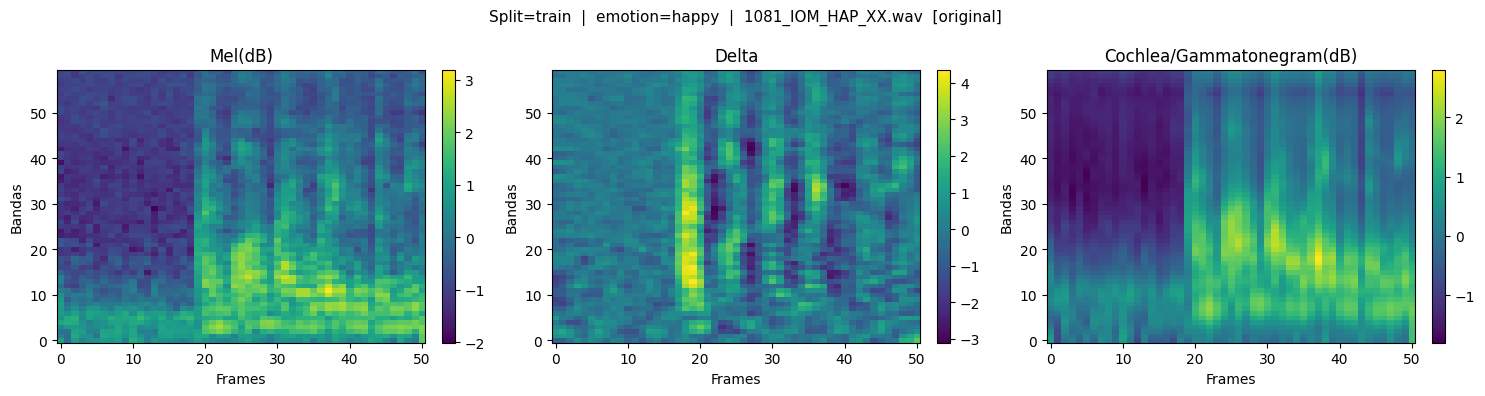

shape=(3, 60, 51)  dtype=torch.float32  label_idx=3


In [22]:
%matplotlib inline

def plot_sample(split='train', idx=None):
    out_path = os.path.join(OUT_DIR_TENSORS, f"{split}_tensors.pt")
    pack = torch.load(out_path, map_location='cpu', weights_only=False)
    x, y, meta = pack['x'], pack['y'], pack['meta']

    if idx is None:
        idx = random.randint(0, len(x) - 1)

    tensor = x[idx]   # [3, N_MELS, TARGET_FRAMES]
    label  = IDX_TO_EMOTION.get(y[idx].item(), '?')
    m      = meta[idx]

    titles = ["Mel(dB)", "Delta", "Cochlea/Gammatonegram(dB)"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Split={split}  |  emotion={label}  |  {m['filename']}  [{m['version']}]", fontsize=11)

    for c in range(3):
        im = axes[c].imshow(tensor[c].numpy(), aspect='auto', origin='lower', cmap='viridis')
        axes[c].set_title(titles[c])
        axes[c].set_xlabel("Frames")
        axes[c].set_ylabel("Bandas")
        plt.colorbar(im, ax=axes[c], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
    print(f"shape={tuple(tensor.shape)}  dtype={tensor.dtype}  label_idx={y[idx].item()}")

plot_sample('train')

## 12. Copying tensors to Drive

We copy our tensor split to Drive to import it in its respective training notebook.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!cp -r {OUT_DIR_TENSORS} /content/drive/MyDrive/